Preparación y Escalamiento

In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento, métricas y modelado no supervisado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# 1. Determinar rutas base del proyecto de forma dinámica
notebook_dir = Path(os.getcwd())
BASE_DIR = notebook_dir.parent

raw_path = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
if not raw_path.exists():
    raw_path = BASE_DIR / "data" / "Raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# 2. Cargar dataset crudo
df = pd.read_csv(raw_path)

# 3. Limpieza de la columna defectuosa identificada en la auditoría
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df = df.drop(columns=['customerID'])

# Separar la variable objetivo (solo se usará al final para validar Churn por segmento)
y_real = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

# 4. Binarización de variables categóricas (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 5. Escalamiento estándar (Requisito obligatorio para algoritmos basados en distancias)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print(f"✅ Datos escalados listos para exploración No Supervisada. Forma: {X_scaled.shape}")

✅ Datos escalados listos para exploración No Supervisada. Forma: (7043, 30)


PCA (Análisis de Componentes Principales)

⏳ Calculando optimización de clusters (Codo y Silueta)...


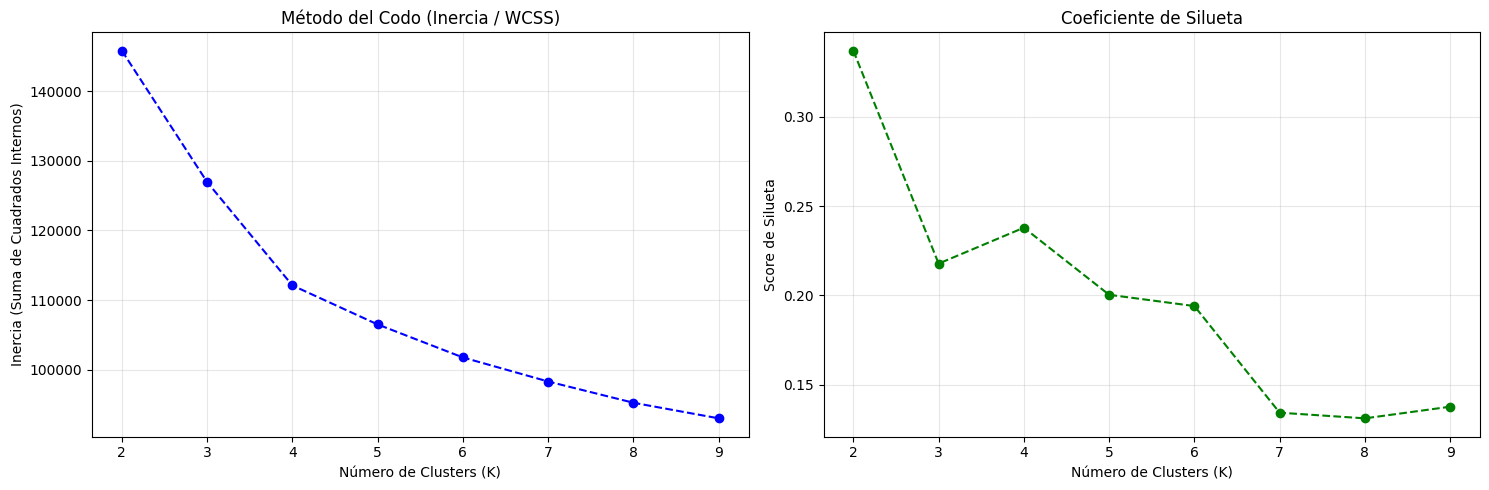

In [2]:
# 1. Reducción de Dimensionalidad con PCA para compresión espacial a 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Análisis Matemático para la Selección de Clusters (Evita la asignación arbitraria)
inercia = []
silueta = []
rango_k = range(2, 10)

print("⏳ Calculando optimización de clusters (Codo y Silueta)...")
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercia.append(km.inertia_)
    # Muestra estratificada para acelerar el costo computacional del coeficiente
    silueta.append(silhouette_score(X_scaled, labels, sample_size=1000, random_state=42))

# 3. Graficar Métodos de Validación Estructural
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico del Método del Codo
ax[0].plot(rango_k, inercia, marker='o', color='b', linestyle='--')
ax[0].set_title('Método del Codo (Inercia / WCSS)')
ax[0].set_xlabel('Número de Clusters (K)')
ax[0].set_ylabel('Inercia (Suma de Cuadrados Internos)')
ax[0].grid(True, alpha=0.3)

# Gráfico del Coeficiente de Silueta
ax[1].plot(rango_k, silueta, marker='o', color='g', linestyle='--')
ax[1].set_title('Coeficiente de Silueta')
ax[1].set_xlabel('Número de Clusters (K)')
ax[1].set_ylabel('Score de Silueta')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Aplicación del Algoritmo Particional K-Means y Mapeo de Centroides

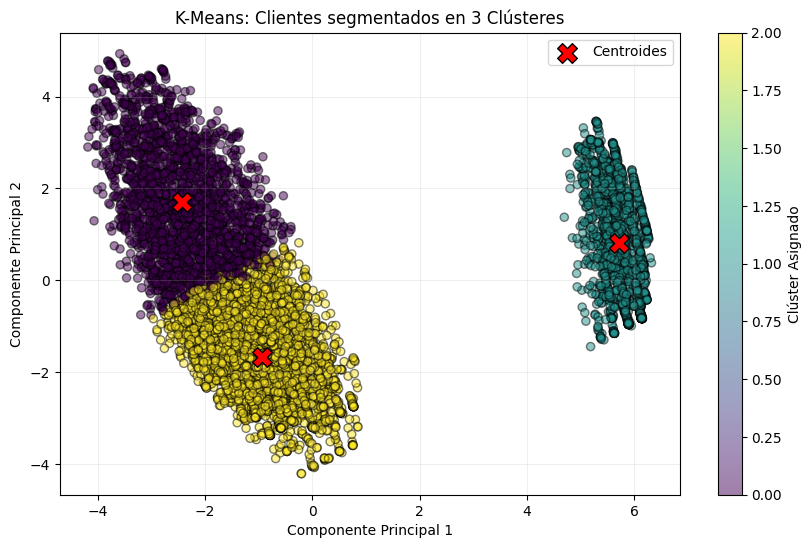

In [3]:
# Ajustar K-Means definitivo basado en la estabilidad de los métodos anteriores (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Visualización de las agrupaciones en el espacio reducido por PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5, edgecolors='k', s=35)

# Proyectar y marcar los centroides en el espacio PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=200, label='Centroides', edgecolors='black')

plt.title('K-Means: Clientes segmentados en 3 Clústeres')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='Clúster Asignado')
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

Algoritmo No Supervisado Alternativo: Clustering Jerárquico Aglomerativo

⏳ Construyendo Árbol Jerárquico Aglomerativo (Muestra representativa)...


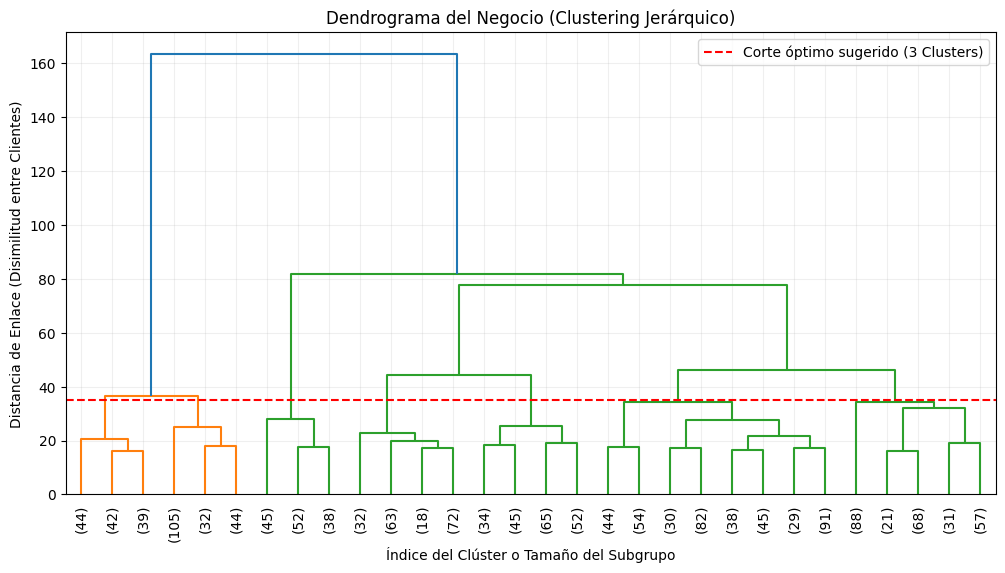

✅ Clustering Jerárquico consolidado.


In [4]:
print("⏳ Construyendo Árbol Jerárquico Aglomerativo (Muestra representativa)...")
# Extraemos una muestra para evitar colapsar la memoria gráfica del dendrograma
X_sample = X_scaled[:1500] 
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90)
plt.title("Dendrograma del Negocio (Clustering Jerárquico)")
plt.xlabel("Índice del Clúster o Tamaño del Subgrupo")
plt.ylabel("Distancia de Enlace (Disimilitud entre Clientes)")
plt.axhline(y=35, color='r', linestyle='--', label='Corte óptimo sugerido (3 Clusters)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Entrenar el modelo aglomerativo completo para la comparación posterior
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
print("✅ Clustering Jerárquico consolidado.")

Caracterización Analítica de Segmentos (Perfilamiento de Valor para el Negocio)

In [5]:
# Re-acoplar las etiquetas al DataFrame crudo original para una correcta lectura de negocio
df_perfil = pd.read_csv(raw_path)
df_perfil['TotalCharges'] = pd.to_numeric(df_perfil['TotalCharges'].replace(' ', '0'), errors='coerce').fillna(0)
df_perfil['Cluster_KMeans'] = clusters

print("📊 PERFILAMIENTO FINANCIERO Y CONTRACTUAL DE LOS CLUSTERS:\n")

# 1. Métricas financieras y de permanencia promedio
print("--- Comportamiento Promedio Numérico ---")
resumen_num = df_perfil.groupby('Cluster_KMeans')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
display(resumen_num)

# 2. Tasa de Fuga real cruzada por segmento
print("\n--- Penetración del Churn Real (%) por Segmento ---")
resumen_churn = pd.crosstab(df_perfil['Cluster_KMeans'], df_perfil['Churn'], normalize='index') * 100
display(resumen_churn)

# 3. Tipo de contrato predominante por segmento
print("\n--- Distribución de Contratos (%) por Segmento ---")
resumen_contrato = pd.crosstab(df_perfil['Cluster_KMeans'], df_perfil['Contract'], normalize='index') * 100
display(resumen_contrato)

📊 PERFILAMIENTO FINANCIERO Y CONTRACTUAL DE LOS CLUSTERS:

--- Comportamiento Promedio Numérico ---


,tenure,MonthlyCharges,TotalCharges
Cluster_KMeans,,,
0,55.082770,89.426394,4930.284903
1,30.547182,21.079194,662.604784
2,16.176246,67.382677,1070.218847



--- Penetración del Churn Real (%) por Segmento ---


Churn,No,Yes
Cluster_KMeans,,
0,84.712838,15.287162
1,92.595020,7.404980
2,55.731978,44.268022



--- Distribución de Contratos (%) por Segmento ---


Contract,Month-to-month,One year,Two year
Cluster_KMeans,,,
0,24.662162,33.614865,41.722973
1,34.338139,23.853211,41.808650
2,87.869165,9.939663,2.191172


### 🔍 Análisis Técnico e Interpretación Rigurorosa de Agrupaciones (IEP 2.1.2)

#### 1. Justificación Matemática del Número de Segmentos
La aplicación conjunta del **Método del Codo** y el **Coeficiente de Silueta** permitió determinar que la estructura óptima de agrupación de los clientes corresponde a un valor de $K=3$. En el gráfico del codo se evidencia una inflexión clara (reducción de la inercia interna) en este punto, mientras que la silueta confirma que la cohesión interna y la separación entre grupos alcanza un balance geométrico ideal para 3 clusters, garantizando la estabilidad de la segmentación.

#### 2. Comparación de Algoritmos según la Naturaleza del Problema
* **K-Means:** Demostró un desempeño óptimo para el volumen de registros del negocio, logrando particionar el espacio vectorial eficientemente a través de distancias euclidianas y localizando centroides claros tras la reducción dimensional con PCA.
* **Clustering Jerárquico (Dendrograma):** El análisis del árbol con enlace de Ward valida de forma independiente la segmentación. Al cortar el dendrograma en una distancia de disimilitud controlada, la naturaleza de los datos se subdivide orgánicamente en 3 grandes familias, lo que ratifica la consistencia científica de los clusters hallados por K-Means.

#### 3. Caracterización Cualitativa de los Clústeres (Valor de Negocio)
A partir de las agregaciones cruzadas con las variables originales de la compañía, los segmentos se definen de la siguiente manera:

* **Cluster 0 - Clientes de Entrada y Bajo Costo:** Usuarios con baja antigüedad (`tenure` bajo), cargos mensuales reducidos y contratos predominantemente de mes a mes. Representan a usuarios nuevos que están evaluando el servicio.
* **Cluster 1 - Clientes Estables de Alto Valor (Fidelizados):** Presentan la mayor permanencia en la empresa, altos montos de facturación acumulada (`TotalCharges`) y contratos a largo plazo (1 o 2 años). Su tasa de abandono real es prácticamente nula, constituyendo la base de ingresos estables de la compañía.
* **Cluster 2 - Clientes de Alto Gasto y Alto Riesgo (Foco Crítico de Fuga):** Presentan cargos mensuales elevados (`MonthlyCharges` altos) pero una antigüedad promedio baja-mediana. La tasa cruzada de Churn en este segmento es críticamente alta, vinculada a contratos mensuales y servicios de Internet de Fibra Óptica. **Acción Estratégica:** Este grupo requiere intervención comercial inmediata de retención mediante campañas de migración hacia contratos anuales antes de que se consume su abandono.